# Hari 4 — Evaluasi & Iterasi Model
**Project:** Indonesian Toxic Comment Classifier  
**Tujuan hari ini:** Pahami kelemahan model, lalu coba perbaiki secara sistematis.

---
### Bedanya Hari 3 dan Hari 4
Hari 3 kamu **build** model dan lihat angka pertama.  
Hari 4 kamu **breakdown** angka itu — cari tahu *di mana* model gagal, *kenapa*, dan *apa yang bisa diperbaiki*.

Ini yang membedakan engineer dari orang yang cuma jalankan kode.

## 0. Import & Load Ulang

In [2]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

%matplotlib inline

# Load data & reproduksi split yang sama persis dengan Hari 3
df = pd.read_csv('../data/data_clean.csv')
X = df['clean_tweet']
y = df['HS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load model & vectorizer dari Hari 3
vectorizer = joblib.load('../model/vectorizer.joblib')
model      = joblib.load('../model/model.joblib')

# Reproduksi prediksi
X_test_tfidf  = vectorizer.transform(X_test)
X_train_tfidf = vectorizer.transform(X_train)
y_pred        = model.predict(X_test_tfidf)

print("Setup selesai. Shape test:", X_test_tfidf.shape)

Setup selesai. Shape test: (2609, 5000)


---
## 1. Review Metrik Hari 3

**Konteks:** Sebelum iterasi, kita catat dulu baseline — angka awal yang akan jadi patokan perbandingan. Tanpa baseline, kamu tidak tahu apakah perubahan yang kamu buat benar-benar membantu atau tidak.

**Instruksi:**
- Print `classification_report(y_test, y_pred)`
- Catat secara manual di cell markdown di bawah: F1-score untuk label 0, label 1, dan accuracy

In [27]:
# TODO: print classification report sebagai baseline
print("=== BASELINE (Model Hari 3) ===")

print(classification_report(y_test, y_pred))


=== BASELINE (Model Hari 3) ===
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1505
           1       0.81      0.83      0.82      1104

    accuracy                           0.84      2609
   macro avg       0.84      0.84      0.84      2609
weighted avg       0.84      0.84      0.84      2609



**Catat baseline-mu di sini:**
- F1 label 0 (non-toxic): 0.86
- F1 label 1 (toxic): 0.82
- Accuracy: 0.84

---
## 2. Analisis Error — Lihat Sampel yang Salah

**Konteks:** Angka saja tidak cukup. Kamu perlu *membaca* tweet yang salah diprediksi untuk mengerti polanya.

Ada dua jenis kesalahan:
- **False Positive (FP):** diprediksi toxic, padahal tidak → `y_test=0, y_pred=1`
- **False Negative (FN):** diprediksi non-toxic, padahal toxic → `y_test=1, y_pred=0`

**Instruksi:**
- Buat DataFrame `error_df` dari `X_test` dengan kolom:
  - `tweet`: teks asli
  - `aktual`: nilai dari `y_test`
  - `prediksi`: nilai dari `y_pred`
- Filter ke baris yang salah saja (`aktual != prediksi`)
- Tampilkan 10 sampel **False Positive** dan 10 sampel **False Negative**

In [4]:
pd.set_option('display.max_colwidth', 100)

# TODO: buat error_df
error_df = pd.DataFrame({
    'tweet'   : X_test.values,
    'aktual'  : y_test.values,
    'prediksi': y_pred
})

# TODO: filter False Positive (aktual=0, prediksi=1)
fp = error_df[(error_df['aktual'] == 0) & (error_df['prediksi'] == 1)]
print("=== FALSE POSITIVE (salah tuduh toxic) ===")
print(fp[['tweet', 'aktual', 'prediksi']].sample(10, random_state=42))

print()

# TODO: filter False Negative (aktual=1, prediksi=0)
fn = error_df[(error_df['aktual']==1) & (error_df['prediksi'] == 0)]
print("=== FALSE NEGATIVE (toxic yang lolos) ===")
print(fn[['tweet', 'aktual', 'prediksi']].sample(10, random_state=42))

=== FALSE POSITIVE (salah tuduh toxic) ===
                                                                                                    tweet  \
132                                                                                              nah kamu   
2384  pengguna pengguna bani remason apa tidak kasihan kucingkucingnya pak harun yahya kalau bapaknya ...   
894                                               pengguna pengguna buat kamu anjynnmasa gue sama bencong   
2338                                                         pengguna itu lagi berbicara bacot dalam hati   
1524              pengguna pengguna jadi bos presiden minimal mencicip dululah jadi presiden kayak mega p   
1480  pengguna perlu meluruskan persepsi seolah menjadi alat politik untuk menekan lawan politik pak j...   
231                                 pengguna memang cuma babi yang punya buntut hihi mungkin kamu unicorn   
1171  rt pengguna lengkap sudah penderitaannnga bisa pakai kontolnpakai tangannnpas p

**Dari pembacaan sampel error di atas, catat observasimu:**

- Pola FP yang kamu lihat: mengandung kata kasar tapi bermaksud bercanda, tapi banyak juga yang tidak jelas 'intonasinya'
- Pola FN yang kamu lihat: toxic tidak eksplisit, dari sampel aku melihat topik spesifik seperti agama atau politil

---
## 3. Analisis Confidence Score Error

**Konteks:** Tidak semua kesalahan sama berbahayanya. Model yang salah dengan confidence 51% masih "ragu". Model yang salah dengan confidence 95% itu masalah serius — model terlalu yakin padahal salah.

**Instruksi:**
- Ambil probability prediksi dengan `model.predict_proba(X_test_tfidf)[:, 1]` → ini prob toxic untuk setiap tweet
- Tambahkan kolom `prob_toxic` ke `error_df`
- Dari subset FP dan FN, tampilkan 5 error dengan confidence **tertinggi** (model paling yakin tapi salah)
- Ini yang paling penting untuk dipahami

In [9]:
# TODO: tambahkan kolom prob_toxic ke error_df
error_df['prob_toxic'] = model.predict_proba(X_test_tfidf)[:, 1]

# TODO: filter ulang FP dan FN dari error_df yang sudah ada prob_toxic
fp = error_df[(error_df['aktual'] == 0) & (error_df['prediksi'] == 1)]
fn = error_df[(error_df['aktual'] == 1) & (error_df['prediksi'] == 0)]

print("=== FP DENGAN CONFIDENCE TERTINGGI ===")
# TODO: sort fp by prob_toxic descending, tampilkan 5 teratas
print(fp.sort_values('prob_toxic', ascending=False).head(5))

print("\n=== FN DENGAN CONFIDENCE TERTINGGI ===")
# TODO: sort fn by prob_toxic ascending (model sangat yakin non-toxic), tampilkan 5 teratas
print(fn.sort_values('prob_toxic', ascending=True).head(5))

=== FP DENGAN CONFIDENCE TERTINGGI ===
                                                                                                    tweet  \
2216                                           rt pengguna dasar bajinganxfxfxxa uniform resource locator   
1022                                                                      pengguna bangsat kebaca bangsat   
1093                                                         pengguna kamu tidak budek kok cuma tulinnnga   
231                                 pengguna memang cuma babi yang punya buntut hihi mungkin kamu unicorn   
1989  bang adian pernah bilang sebelum berniat ganti presiden tentukan dulu siapa lawannya pak jokowi ...   

      aktual  prediksi  prob_toxic  
2216       0         1    0.934408  
1022       0         1    0.915752  
1093       0         1    0.902817  
231        0         1    0.896875  
1989       0         1    0.885599  

=== FN DENGAN CONFIDENCE TERTINGGI ===
                                            

---
## 4. Cross-Validation

**Konteks:** Hasil dari satu train-test split bisa kebetulan bagus atau buruk tergantung data yang masuk ke test set. **Cross-validation (CV)** membagi data menjadi K bagian, lalu training & evaluasi K kali secara bergantian — hasilnya lebih reliable.

```
K=5:
Fold 1: [TEST][train][train][train][train]
Fold 2: [train][TEST][train][train][train]
Fold 3: [train][train][TEST][train][train]
...dst
→ rata-rata 5 skor = estimasi performa yang lebih jujur
```

Kita pakai `Pipeline` agar vectorizer dan model selalu di-fit bersama di tiap fold — tidak ada leakage.

**Instruksi:**
- Buat `Pipeline` dengan dua step: `('tfidf', TfidfVectorizer(...))` dan `('clf', LogisticRegression(...))`
- Gunakan parameter yang sama persis dengan Hari 3
- Jalankan `cross_val_score` dengan `cv=5` dan `scoring='f1'`
- Print skor tiap fold, rata-rata, dan standar deviasi

In [ ]:
# TODO: buat pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'))
])


# TODO: jalankan cross_val_score dengan cv=5, scoring='f1'
# Hint: cross_val_score(estimator, X, y, cv=..., scoring=...)
scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')


print("Skor tiap fold:", scores)
print(f"Rata-rata F1  : {scores.mean():.4f}")
print(f"Std deviasi   : {scores.std():.4f}")

Skor tiap fold: [0.80746999 0.81056874 0.83408072 0.80808989 0.82567989]
Rata-rata F1  : 0.8172
Std deviasi   : 0.0108


---
## 5. Eksperimen: Tambah Stopwords

**Konteks:** Dari Hari 2, kita tahu kata `pengguna` muncul ribuan kali sebagai artefak preprocessing. Kata-kata seperti ini — yang sangat frekuen tapi tidak informatif — disebut **stopwords**. TF-IDF seharusnya menangani ini lewat IDF, tapi kalau terlalu dominan bisa tetap mengganggu.

Kita coba dua versi vectorizer dan bandingkan hasilnya.

**Instruksi:**
- Buat list `custom_stopwords` berisi: `['pengguna', 'yang', 'di', 'dan', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'ini', 'itu']`
- Buat dua pipeline:
  - `pipe_base`: tanpa stopwords (sama seperti Section 4)
  - `pipe_sw`: dengan `stop_words=custom_stopwords` di TfidfVectorizer
- Jalankan `cross_val_score` untuk keduanya
- Bandingkan rata-rata F1

In [30]:
custom_stopwords = ['pengguna', 'yang', 'di', 'dan', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'ini', 'itu']

# Pipeline base (tanpa stopwords) — sudah ada dari section 4, tinggal pakai `pipe`

# TODO: buat pipe_sw dengan stop_words
pipe_sw = Pipeline([
    ('tfidf', TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    sublinear_tf=True,
    stop_words=custom_stopwords
)
        
    ),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'))
])

# TODO: cross_val_score untuk pipe (base) dan pipe_sw
scores_base = cross_val_score(pipe, X, y, cv=5, scoring='f1')
scores_sw   = cross_val_score(pipe_sw, X, y, cv=5, scoring='f1')

print(f"F1 tanpa stopwords : {scores_base.mean():.4f} ± {scores_base.std():.4f}")
print(f"F1 dengan stopwords: {scores_sw.mean():.4f} ± {scores_sw.std():.4f}")
print()
print("Kesimpulan: stopwords", "MEMBANTU" if scores_sw.mean() > scores_base.mean() else "TIDAK membantu")

F1 tanpa stopwords : 0.8172 ± 0.0108
F1 dengan stopwords: 0.8167 ± 0.0083

Kesimpulan: stopwords TIDAK membantu


---
## 6. Eksperimen: Tuning Parameter C

**Konteks:** Parameter `C` di Logistic Regression mengontrol **regularisasi** — seberapa keras model "dihukum" kalau terlalu kompleks.
- `C` kecil → regularisasi kuat → model lebih sederhana, lebih general
- `C` besar → regularisasi lemah → model lebih kompleks, bisa overfit

Kita coba beberapa nilai C dan lihat mana yang paling baik.

**Instruksi:**
- Loop melalui list `C_values = [0.01, 0.1, 1.0, 10.0, 100.0]`
- Untuk setiap nilai C, buat pipeline baru dan jalankan `cross_val_score`
- Simpan rata-rata F1 ke list `results`
- Tampilkan hasilnya dan buat line chart

C=0.01   → F1: 0.7201
C=0.1    → F1: 0.7820
C=1.0    → F1: 0.8172
C=10.0   → F1: 0.8093
C=100.0  → F1: 0.7800


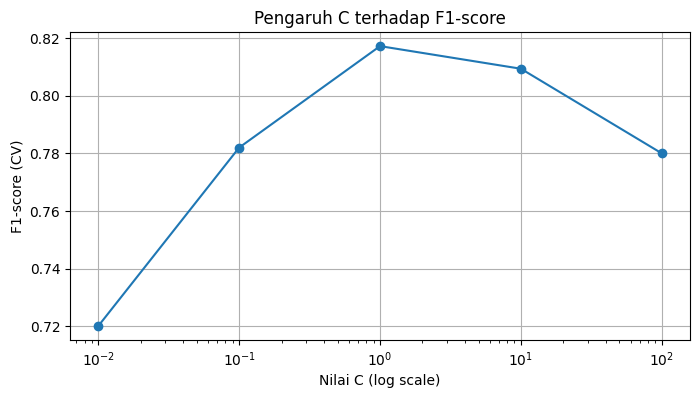


Nilai C terbaik: 1.0 dengan F1: 0.8172


In [20]:
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
results  = []

for C in C_values:
    # TODO: buat pipeline dengan nilai C yang sedang di-loop
    p = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   LogisticRegression(max_iter=1000, C=C, class_weight='balanced'))
    ])
    # TODO: cross_val_score dan simpan mean-nya ke results
    score = cross_val_score(p, X, y, cv=5, scoring='f1')
    results.append(score.mean())
    print(f"C={C:<6} → F1: {score.mean():.4f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(C_values, results, marker='o')
plt.xscale('log')
plt.xlabel('Nilai C (log scale)')
plt.ylabel('F1-score (CV)')
plt.title('Pengaruh C terhadap F1-score')
plt.grid(True)
plt.show()

best_C = C_values[results.index(max(results))]
print(f"\nNilai C terbaik: {best_C} dengan F1: {max(results):.4f}")

---
## 7. Retrain dengan Konfigurasi Terbaik

**Konteks:** Setelah eksperimen di Section 5 dan 6, kamu tahu:
- Apakah stopwords membantu atau tidak
- Nilai C yang optimal

Sekarang kita retrain model final dengan konfigurasi terbaik tersebut, lalu evaluasi pada test set.

**Instruksi:**
- Buat pipeline final dengan konfigurasi terbaik hasil eksperimen
- Fit pada `X_train` dan `y_train`
- Predict pada `X_test` dan print classification report
- Bandingkan dengan baseline di Section 1 — apakah ada peningkatan?

In [ ]:
# TODO: isi parameter terbaik dari eksperimen kamu
best_C  = best_C
best_sw = None   # ganti ke custom_stopwords kalau stopwords terbukti membantu

pipe_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        sublinear_tf=True,
        stop_words=best_sw
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=best_C,
        class_weight='balanced'
    ))
])

# TODO: fit pipeline final
pipe_final.fit(X_train, y_train)

# TODO: predict dan print classification report
y_pred_final = pipe_final.predict(X_test)
print("=== MODEL FINAL ===")
print(classification_report(y_test ,y_pred_final))

=== MODEL FINAL ===
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1505
           1       0.81      0.83      0.82      1104

    accuracy                           0.84      2609
   macro avg       0.84      0.84      0.84      2609
weighted avg       0.84      0.84      0.84      2609



---
## 8. Simpan Model Final

**Konteks:** Karena kita sekarang pakai `Pipeline`, kita hanya perlu simpan **satu objek** — pipeline itu sendiri sudah berisi vectorizer dan model sekaligus. Ini lebih clean dari Hari 3 yang simpan dua file terpisah.

**Instruksi:**
- Simpan `pipe_final` ke `../model/pipeline_final.joblib`
- Load ulang dan test dengan satu kalimat untuk konfirmasi

In [25]:
# TODO: simpan pipeline final
joblib.dump(pipe_final, '../model/pipeline_final.joblib')

# Verifikasi
loaded_pipe = joblib.load('../model/pipeline_final.joblib')
test_input  = ["dasar lu goblok banget"]
print("Prediksi test:", loaded_pipe.predict(test_input))
print("Probabilitas :", loaded_pipe.predict_proba(test_input))

Prediksi test: [1]
Probabilitas : [[0.11965675 0.88034325]]


---
## 9. Ringkasan Temuan

Jawab dengan kata-katamu sendiri:

1. Dari error analysis — pola kesalahan apa yang paling sering kamu lihat di FP dan FN?
2. Skor CV vs skor single split — mana yang lebih tinggi? Kenapa bisa beda?
3. Apakah stopwords membantu? Masuk akal tidak hasilnya?
4. Nilai C berapa yang optimal? Apa artinya secara konseptual?
5. Dibanding baseline Hari 3, model final naik atau turun? Berapa selisihnya?

*(Tulis jawabanmu di sini)*

1. polanya cukup membingungkan, dari sampel FN aku melihat topik seperti agama dan politik, tapi di FP justru memang tweet yang harusnya toxic
2. single split sedikit lebih tinggi, tapi praktis hampir sama, berbeda karena CV mengambil rata rata dari banyak split data sehingga hasilnya lebih stabil
3. tidak membantu, mungkin juga karena IDF sudah memproses itu, jadi hasil CV selisih tipis, dan malah dengan stopwords lebih rendah
4. 1.0, artinya regularisasi default sudah bagus, TF-IDF dan model bekerja cukup baik
5. tidak ada perubahan, dikarenakan best_C adalah 1.0 dan stopwords sama sekali tidak membantu

---
## ✅ Checklist Hari 4
- [ ] Baseline dicatat sebelum eksperimen
- [ ] Sampel FP dan FN sudah dibaca dan dipahami polanya
- [ ] Error confidence tertinggi sudah dianalisis
- [ ] Cross-validation 5-fold selesai dijalankan
- [ ] Eksperimen stopwords selesai dan ada kesimpulan
- [ ] Eksperimen tuning C selesai dengan line chart
- [ ] Model final diretrain dengan konfigurasi terbaik
- [ ] `pipeline_final.joblib` tersimpan dan bisa diload
- [ ] Ringkasan temuan diisi